# 05 Stats

Answers the three research questions from the stage 4 pieces. Tables go to `outputs/tables/05_*.csv`; the report figures are drawn from those tables by `src/reclaim/figures.py` and written to `outputs/figures/fig*.{pdf,svg,png}` (170 mm wide, for an A4 report).

Every reclaimed piece falls into one of three groups:

- **habitat**: natural or built habitat on the baseline map
- **works**: Openland and Water at Pulau Tekong (`habitat.works` in `config.yaml`). Both maps were drawn while Tekong was being reclaimed, so these are bunded basins and sand fill, not natural habitat.
- **unmapped**: outside both maps (`Unmapped / open water`)

RQ3 only uses the area the baseline map covers and leaves the works out of both the numerator and the denominator. Its 95% intervals come from resampling the reclamation polygons of each period (`stats.bootstrap_n` draws).

In [1]:
from IPython.display import Image, display
from reclaim import config, figures, stats
cfg = config.load()
pieces, tables = stats.run(cfg)
pieces.groupby(['baseline', 'group']).area_ha.sum().unstack().round(1)

wrote outputs/tables/05_rq1_annual.csv
wrote outputs/tables/05_rq2_habitat.csv
wrote outputs/tables/05_rq3_selection.csv


group,habitat,unmapped,works
baseline,,,
map_2010_11,35.2,472.6,323.4
map_2018,109.7,1224.4,265.6


## RQ1: how much new land each year, and where

SLA records land when it is surveyed and gazetted; the satellite sees it when it emerges. Totals are comparable, single years are not.

In [2]:
tables['05_rq1_annual']

,year,detected_ha,sla_increase_ha
0,2016,156.8,60.0
1,2017,349.6,180.0
2,2018,324.8,270.0
3,2019,268.9,150.0
4,2020,238.7,260.0
5,2021,192.5,480.0
6,2022,330.2,120.0
7,2023,210.5,90.0
8,2024,142.0,50.0
9,2025,216.8,860.0


## RQ2: which habitats the new land replaced

In [3]:
tables['05_rq2_habitat']

,baseline,group,HABITAT_TYPE,area_ha,share_of_all_pct,share_of_mapped_habitat_pct
4,map_2010_11,habitat,Other Vegetation,12.08,0.50,34.27
2,map_2010_11,habitat,Mudflat,6.71,0.28,19.05
1,map_2010_11,habitat,Mangrove,5.55,0.23,15.75
10,map_2010_11,habitat,Water,4.89,0.20,13.88
9,map_2010_11,habitat,Shallow Water,1.97,0.08,5.60
6,map_2010_11,habitat,Sandflat,1.42,0.06,4.03
0,map_2010_11,habitat,Built-up,1.20,0.05,3.42
8,map_2010_11,habitat,Seagrass and Algae,0.91,0.04,2.58
5,map_2010_11,habitat,Rock Bund,0.28,0.01,0.81
7,map_2010_11,habitat,Sandy Beach,0.15,0.01,0.42


## RQ3: were some habitats reclaimed more than their share?

The numerators are small (under 1 ha to about 25 ha per class), so read the intervals, not just the point estimates.

In [4]:
tables['05_rq3_selection']

,baseline,HABITAT_TYPE,map_ha,map_share_pct,reclaimed_ha,reclaimed_share_pct,selection_ratio,ci_low,ci_high
7,map_2010_11,Other Vegetation,4930.598,40.023,12.078,34.274,0.856,0.219,1.423
5,map_2010_11,Mudflat,368.735,2.993,6.714,19.052,6.365,1.538,12.702
4,map_2010_11,Mangrove,956.927,7.768,5.550,15.749,2.028,0.299,4.872
18,map_2010_11,Water,3312.334,26.887,4.890,13.877,0.516,0.081,1.307
16,map_2010_11,Shallow Water,122.002,0.990,1.972,5.595,5.650,0.000,16.113
12,map_2010_11,Sandflat,109.025,0.885,1.420,4.030,4.553,0.228,13.158
0,map_2010_11,Built-up,1054.439,8.559,1.204,3.418,0.399,0.074,0.975
15,map_2010_11,Seagrass and Algae,118.985,0.966,0.909,2.580,2.671,0.657,4.407
8,map_2010_11,Rock Bund,53.652,0.436,0.284,0.806,1.852,0.170,4.592
13,map_2010_11,Sandy Beach,100.190,0.813,0.148,0.420,0.516,0.002,1.291


## Report figures

wrote outputs/figures/fig1_annual.pdf / .svg / .png


wrote outputs/figures/fig2_map.pdf / .svg / .png
wrote outputs/figures/fig3_composition.pdf / .svg / .png


wrote outputs/figures/fig4_habitat.pdf / .svg / .png
wrote outputs/figures/fig5_selection.pdf / .svg / .png


wrote outputs/figures/fig6_hotspots.pdf / .svg / .png


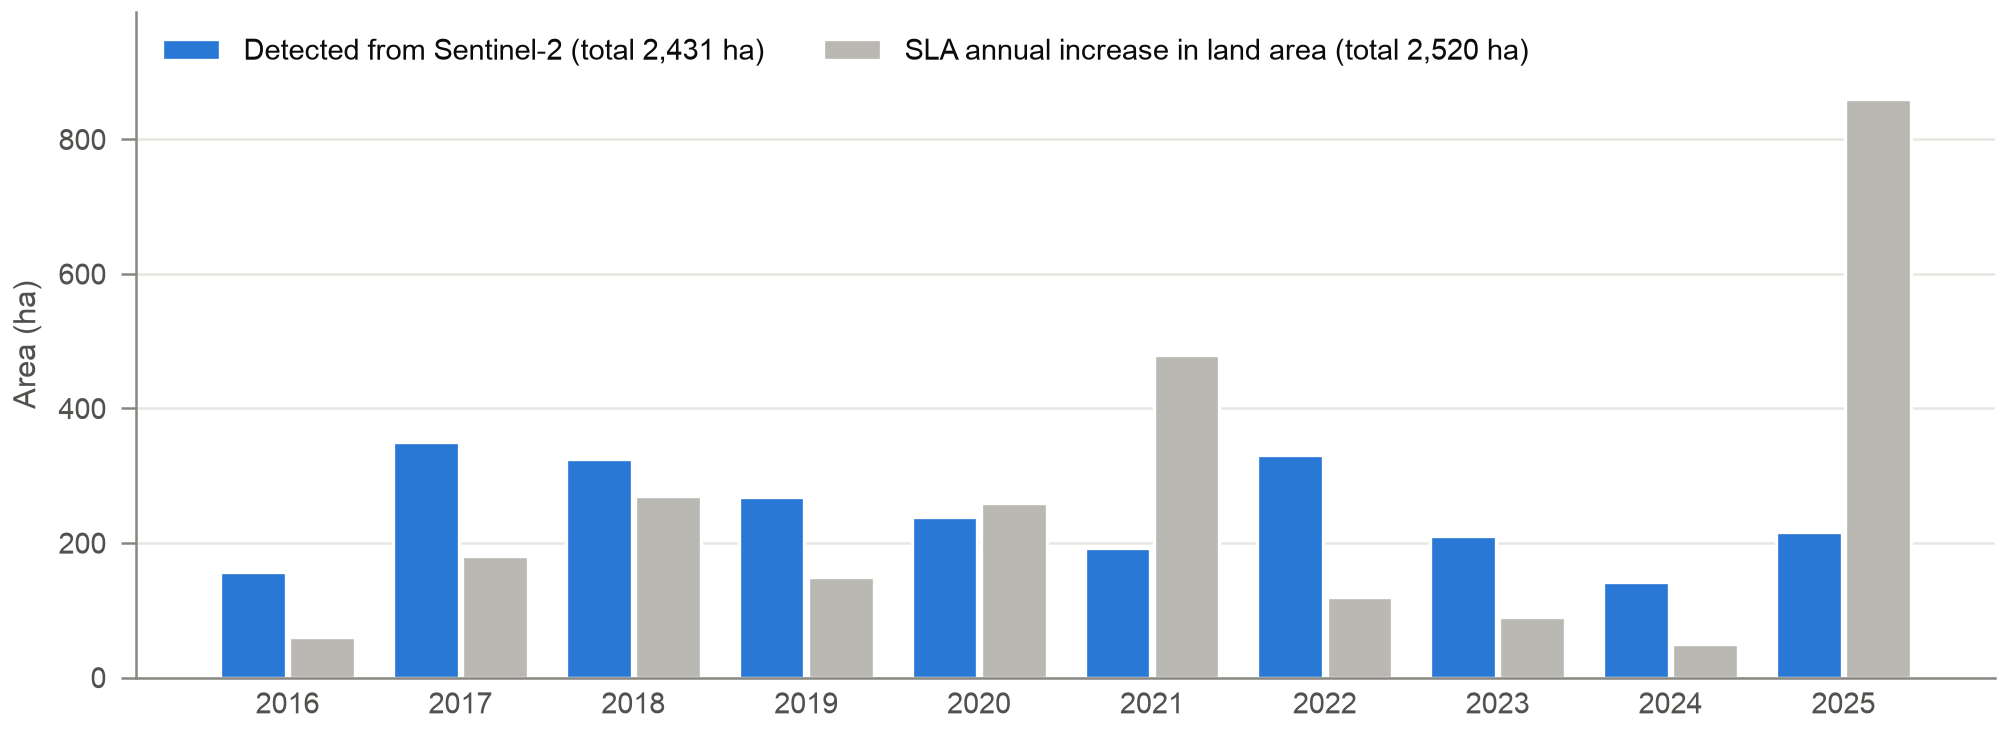

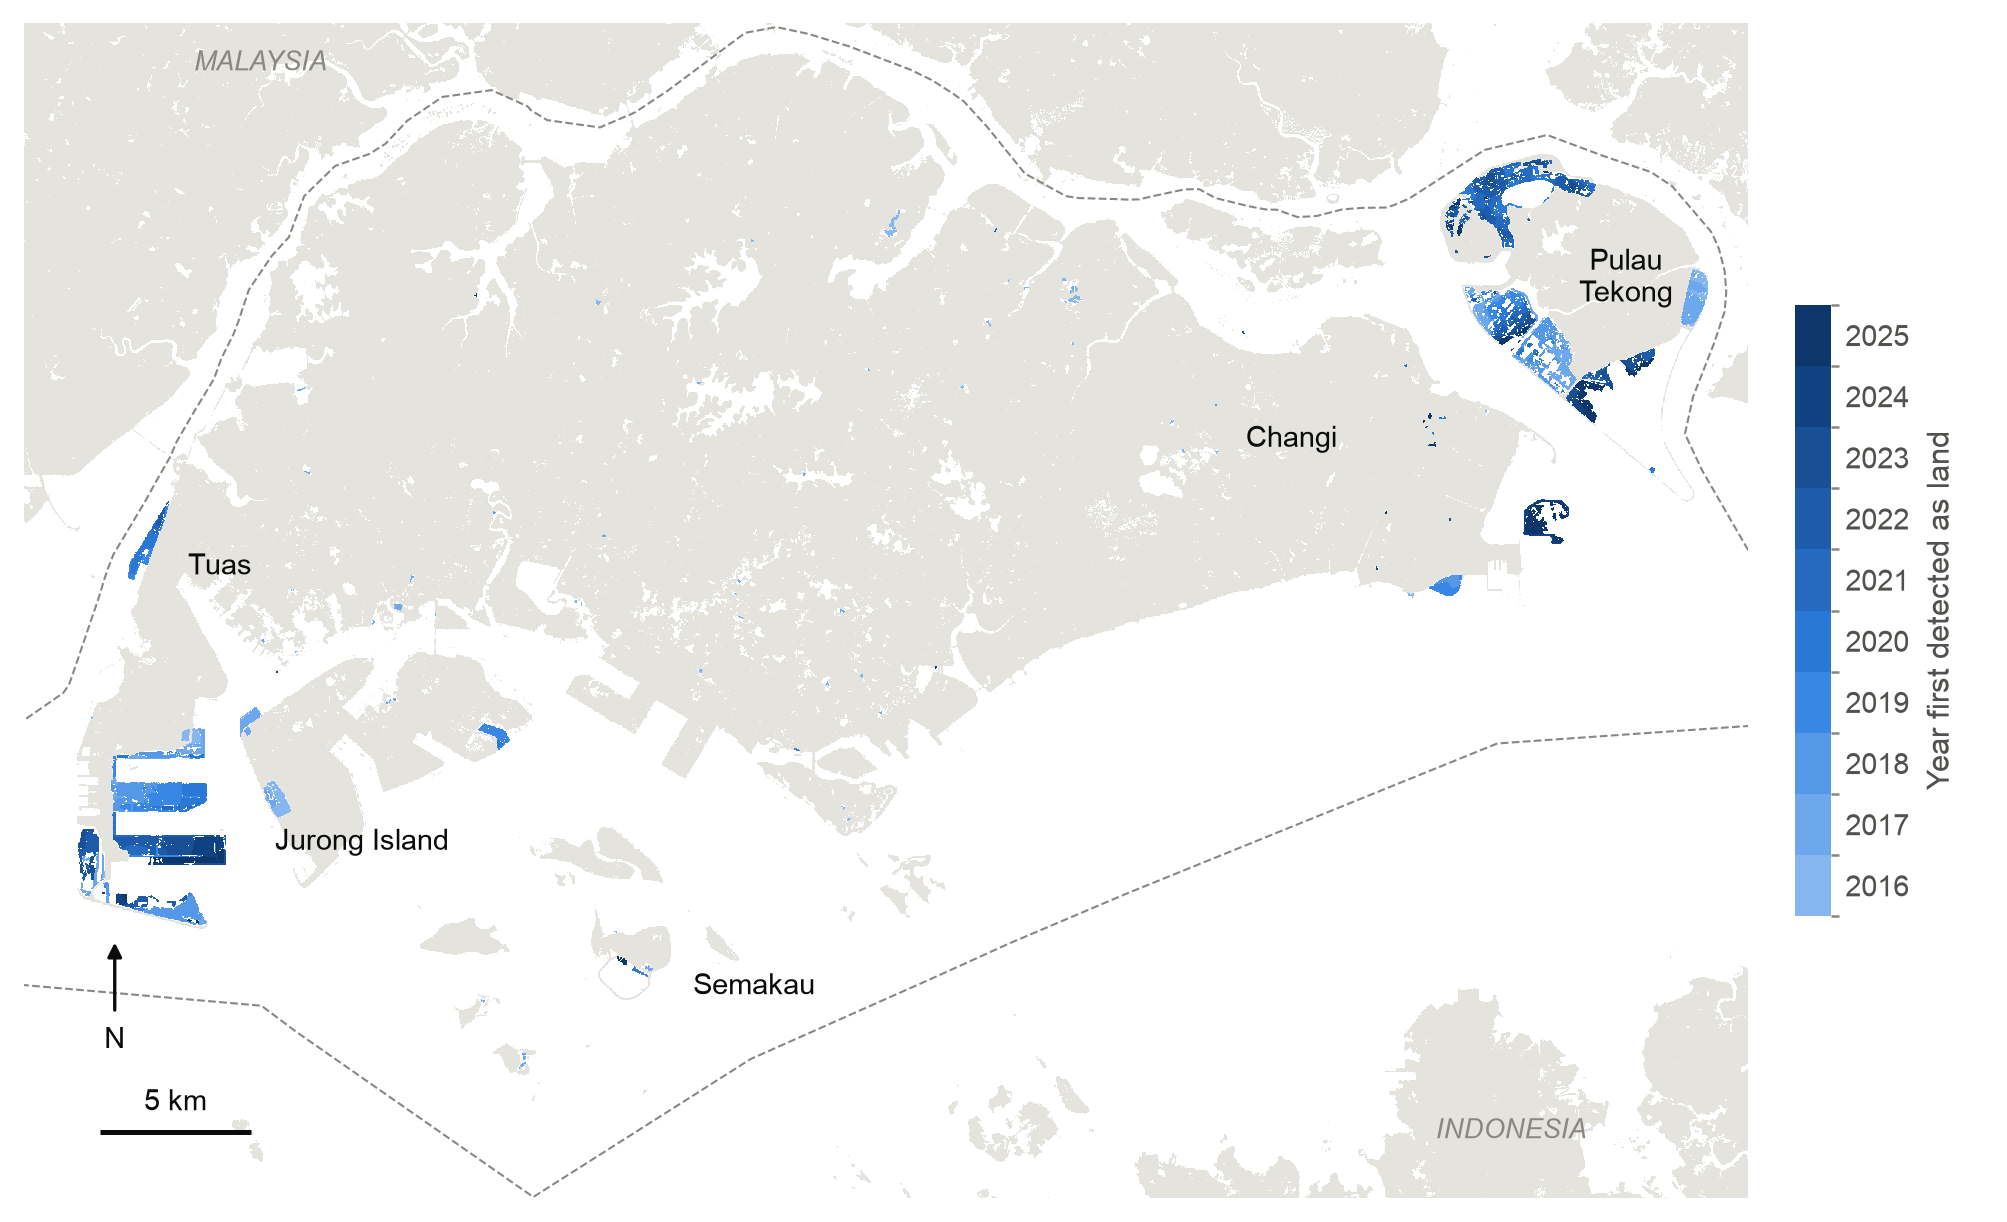

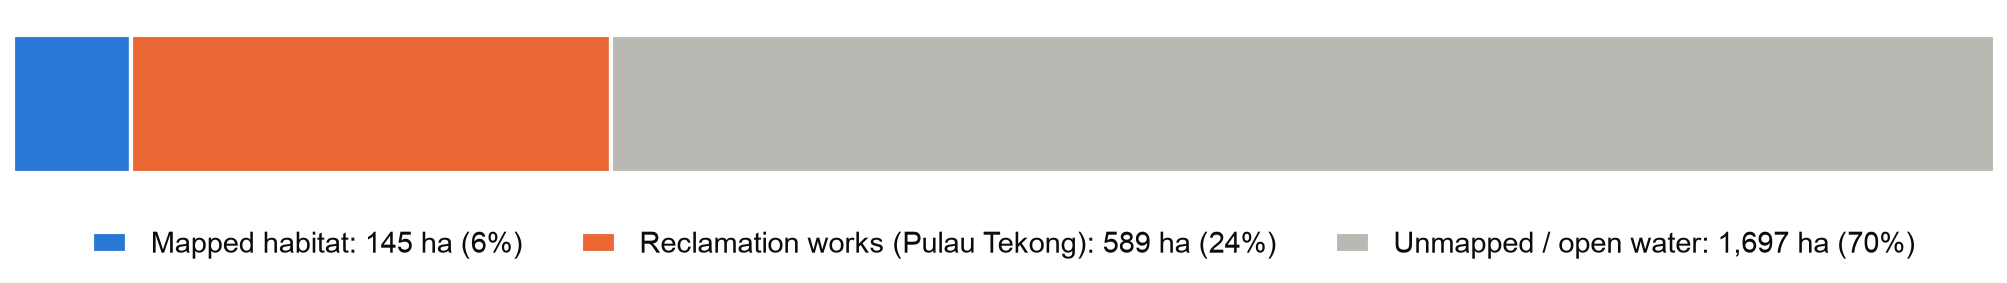

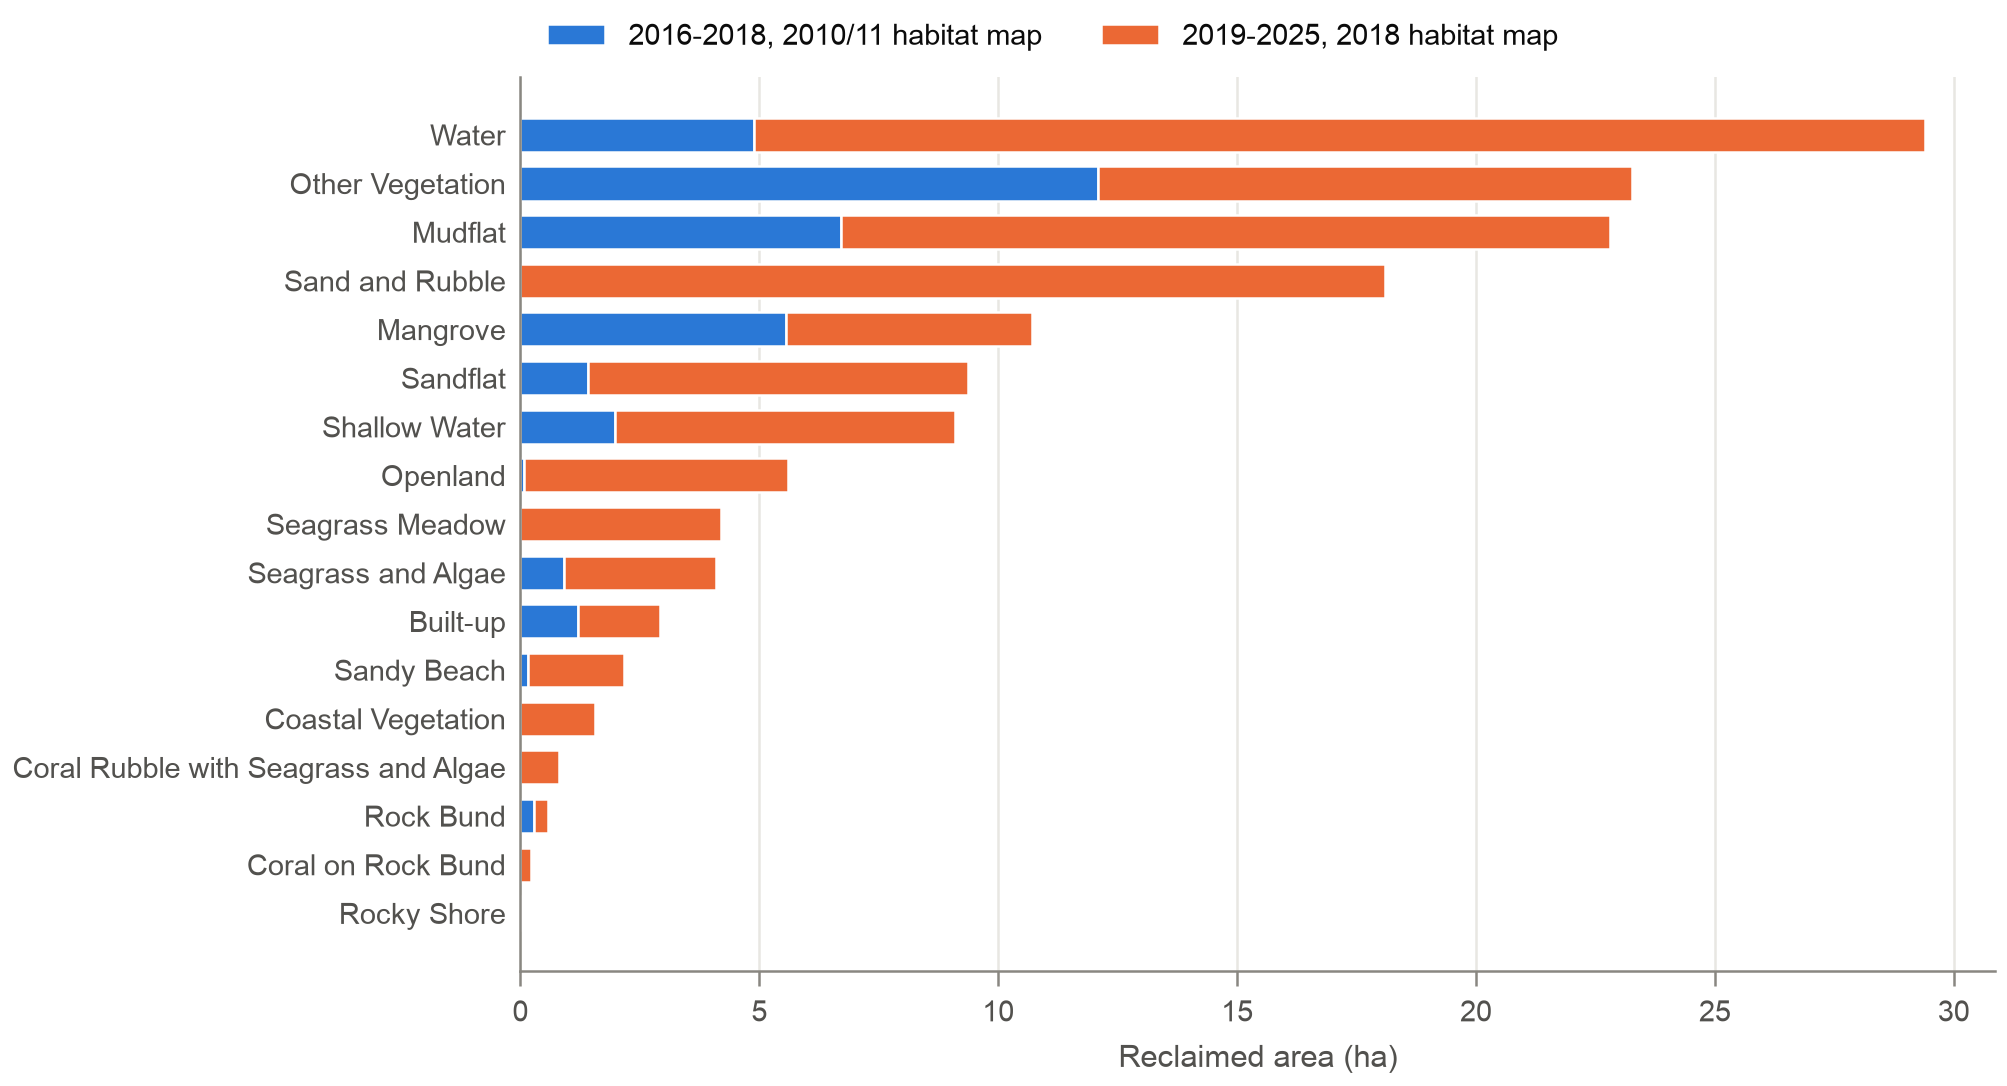

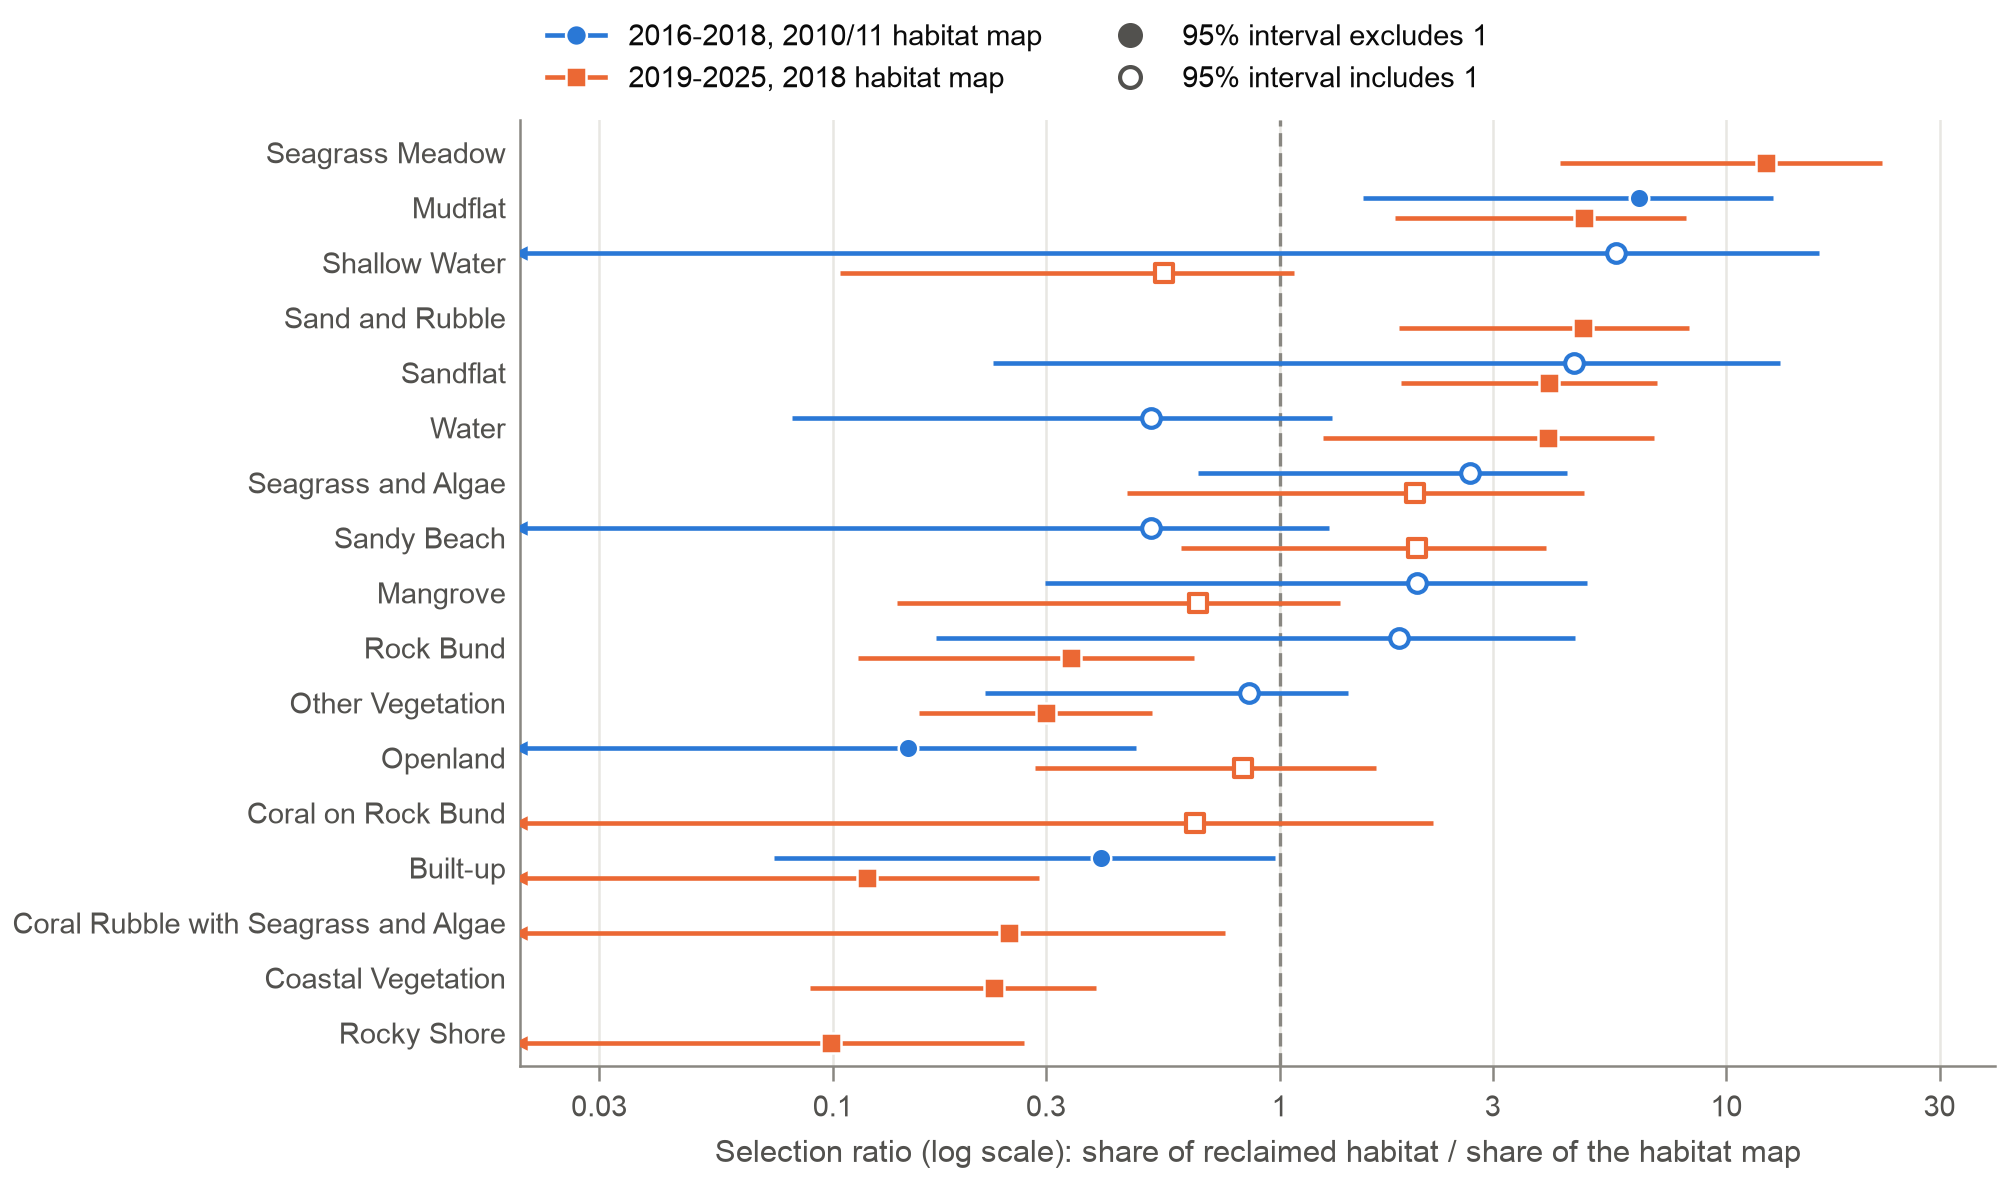

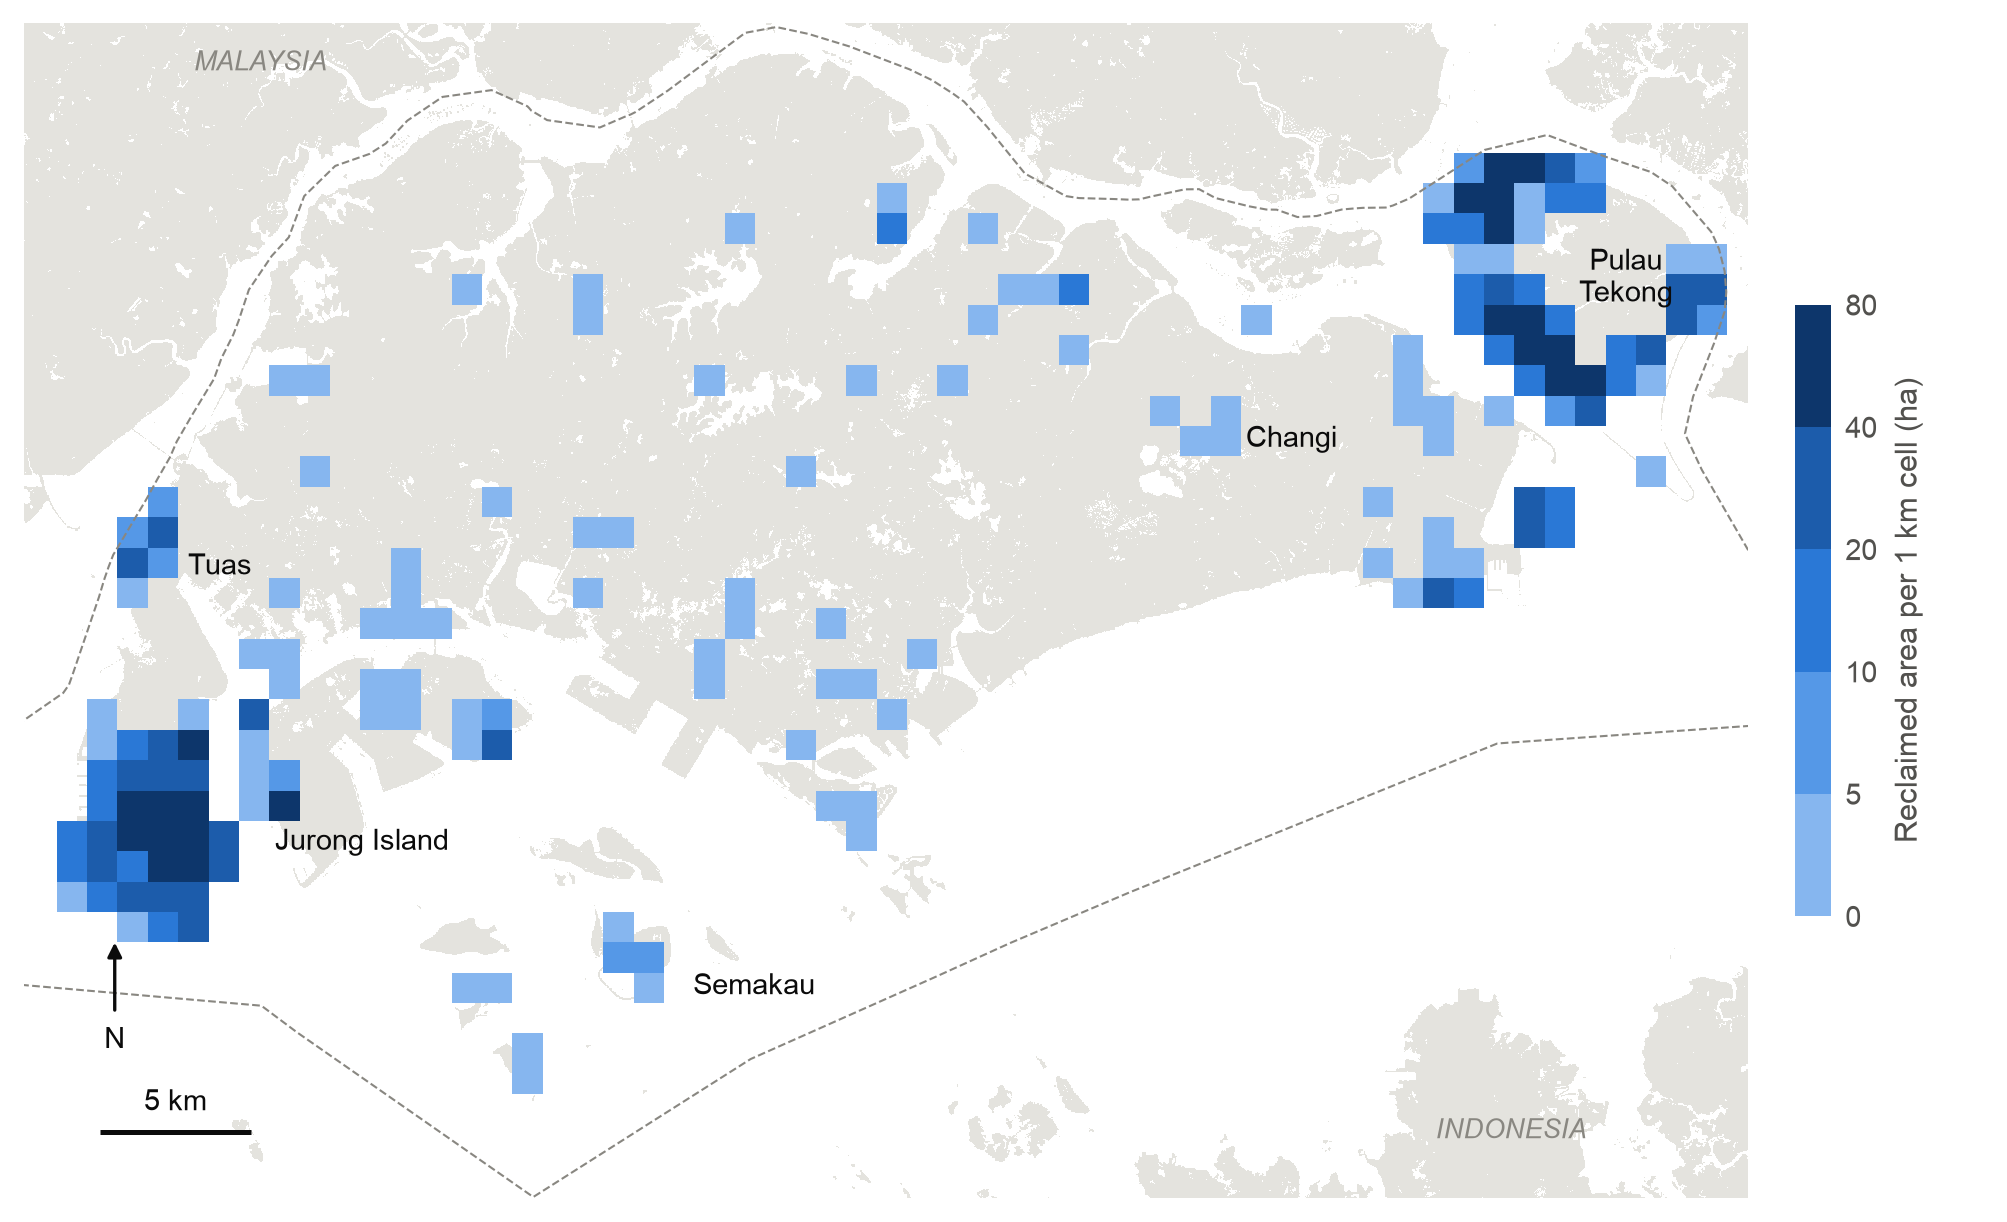

In [5]:
figures.run(cfg)
for name in figures.FIGURES:
    display(Image(filename=str(figures.FIG / f'{name}.png'), width=900))